# Task 3 - Content-based Recommender

A content-based recommendation engine buil on audio-feature similarity, reusing artifacts from the previous two notebooks: the K=5 macro-genre mapping (classification) and the tuned regression model(popularity), via a "hidden gems" mode.

**Approach**: Nearest Neighbor search on scaled audio features (cosine similarity). Track-level mood clustering (valence-arousal plane) as an optional attribute.

**Evaluation**: Genre-agreement@10 (native + macro), popularity bias check (standard vs. hidden gems mode). 

#### Setup and data splitting
For this task, train set will be used as a catalogue, while test set as the queries, i.e. seed tracks to generate 10 similar recommendations.

In [ ]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config
from src.data_preprocessor import load_and_clean_data

RANDOM_STATE = 42

df = load_and_clean_data(str(ROOT / config.DATA_PATH))

# Same split as in other notebooks
# Train = catalogue, test = query, new track to ask recommendations for
X_train, X_test = train_test_split(df, test_size=0.2, stratify=df['track_genre'], random_state=RANDOM_STATE)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# Using the same classification mapping -> 5 macro-genres
genre_to_macro = joblib.load(ROOT / "notebooks" / "genre_to_macro.pkl")
X_train["macro_genre"] = X_train["track_genre"].map(genre_to_macro)
X_test["macro_genre"] = X_test["track_genre"].map(genre_to_macro) 

#### Similarity Feature Space
Continuous audio features (scaled) + discrete features (one-hot) + binary passthrough. Popularity and artist average popularity are excluded (see function documentation string).

In [ ]:
def build_similarity_features(X_ref, X_query=None):
    """
    Build the similarity feature space: scaled continuous audio features +
    one-hot encoded discrete features. Popopularity and artist popularity
    are not included in the similarity space, as they may dominate audio similarity 
    and are not relevant for the recommendation task.
    """
    prep = ColumnTransformer([
        ("scaler", StandardScaler(), config.CONTINUOUS_FEATURES),
        ("discrete_ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), config.DISCRETE_FEATURES),
        ("bin", "passthrough", config.BINARY_FEATURES),
    ])
    X_ref_enc = prep.fit_transform(X_ref)
    if X_query is not None:
        X_query_enc = prep.transform(X_query)
        return prep, X_ref_enc, X_query_enc
    return prep, X_ref_enc

sim_prep, X_train_enc, X_test_enc = build_similarity_features(X_train, X_test)

#### Mood Clustering

Track-level K-Means on `valence`/`energy`, a standard approach in emotion recognition (valence-arousal model). Kept to 2 dimensions for interpretability: 4 clusters that can be named and plotted.

In [41]:
mood_features = ["valence", "energy"]
mood_scaler = StandardScaler()
mood_scaled_train = mood_scaler.fit_transform(X_train[mood_features])

km_mood = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
X_train["mood_cluster"] = km_mood.fit_predict(mood_scaled_train)
X_test["mood_cluster"] = km_mood.predict(mood_scaler.transform(X_test[mood_features]))

In [42]:
centroids = pd.DataFrame(km_mood.cluster_centers_, columns=mood_features)
centroids_original_scale = pd.DataFrame(
    mood_scaler.inverse_transform(km_mood.cluster_centers_), columns=mood_features
)
print(centroids_original_scale)

    valence    energy
0  0.596589  0.484259
1  0.278501  0.825430
2  0.751226  0.810150
3  0.206717  0.285733


In [43]:
# Building a mapping on those numbers
mood_labels = {}
for clustes_id, row in centroids_original_scale.iterrows():
    if row["valence"] >= 0.5 and row["energy"] >= 0.5:
        mood_labels[clustes_id] = "Happy/Energetic"
    elif row["valence"] >= 0.5 and row["energy"] < 0.5:
        mood_labels[clustes_id] = "Calm/Content"  
    elif row["valence"] < 0.5 and row["energy"] >= 0.5:
        mood_labels[clustes_id] = "Tense/Angry"
    else:
        mood_labels[clustes_id] = "Sad/Melancholic" 

X_train["mood_label"] = X_train["mood_cluster"].map(mood_labels)
X_test["mood_label"] = X_test["mood_cluster"].map(mood_labels)
print(mood_labels)

{0: 'Calm/Content', 1: 'Tense/Angry', 2: 'Happy/Energetic', 3: 'Sad/Melancholic'}


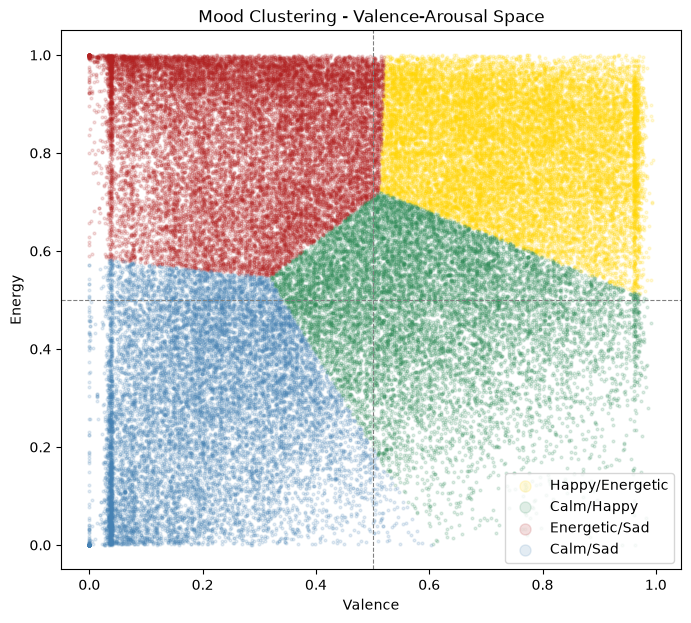

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))
colors = {"Happy/Energetic": "gold", "Calm/Happy": "seagreen", "Energetic/Sad": "firebrick", "Calm/Sad": "steelblue"}

for label, color in colors.items():
    subset = X_train[X_train["mood_label"] == label]
    ax.scatter(subset["valence"], subset["energy"], s=4, label=label, alpha=0.15, color=color)

ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Valence"); ax.set_ylabel("Energy")
ax.set_title("Mood Clustering - Valence-Arousal Space")
ax.legend(markerscale=4)
plt.tight_layout; plt.show()

#### Recommendation engine

Nearest-neighbor search (cosine similarity) on the audio feature space.
`same_macro_genre` and `hidden_gems_only` are optional filters for re-ranking, applied on top of the base similarity search.

In [48]:
nn_model = NearestNeighbors(n_neighbors=10, metric="cosine")
nn_model.fit(X_train_enc)

def recommend(query_idx, k=10, same_macro_genre=False, hidden_gems_only=False, hidden_gem_scores=None):
    query_vec = X_test_enc[query_idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(query_vec, n_neighbors=k*5)  # Get more neighbors to filter later
    candidates = X_train.iloc[indices[0]].copy()
    candidates["similarity"] = 1 - distances[0]

    if same_macro_genre:
        query_macro = X_test.iloc[query_idx]["macro_genre"]
        candidates = candidates[candidates["macro_genre"] == query_macro]
    if hidden_gems_only and hidden_gem_scores is not None:
        candidates["hidden_gem_score"] = hidden_gem_scores.loc[candidates.index]
        candidates = candidates.sort_values("hidden_gem_score", ascending=False)
        display_cols = ["track_name", "artists", "track_genre", "similarity", "hidden_gem_score"]
    else:
        candidates = candidates.sort_values("similarity", ascending=False)
        display_cols = ["track_name", "artists", "track_genre", "similarity"]
    return candidates[display_cols].head(k)

Reusing the tuned regression model to score how much a track's observed popularity falls short of what its audio/artist/genre profile would predict, surfacing stylistically similar but underrated tracks (**hidden gems**).

In [44]:
# Using the previous regression model
regression_model = joblib.load(ROOT / "notebooks" / "final_model.pkl")

y_pred_catalog = regression_model.predict(X_train)
# an high score mean that the model expect a greater popularity than the one observed, so the track is a hidden gem
hidden_gem_scores = pd.Series(y_pred_catalog - X_train["popularity"].values, index=X_train.index)

#### Case studies

A few concrete queries, compared across modes: plain similarity, same macro-genre only, and hidden gems.

In [ ]:
def show_recommendations(query_idx, k=10, **kwargs):
    query = X_test.iloc[query_idx]
    print(f"Query: {query['track_name']} - {query['artists']} ({query['track_genre']}, mood: {query['mood_label']})")
    print("-"*60)
    recs = recommend(query_idx, k=k, **kwargs)
    display(recs)

example_idx = X_test[X_test["track_name"].str.contains("Kuduro", case=False, na=False)].index
query_idx = X_test.index.get_loc(example_idx[0]) if len(example_idx) > 0 else 0
if len(example_idx) > 0:
    show_recommendations(query_idx)
else:
    show_recommendations(0)  # fallback to first track in test set

# same query but filtered for macro-genre
show_recommendations(query_idx, same_macro_genre=True)

# same query, but filtered for hidden gems
show_recommendations(query_idx, hidden_gems_only=True, hidden_gem_scores=hidden_gem_scores)

Query: Danza Kuduro - Version MTO - Lucenzo;Don Omar (french, mood: Happy/Energetic)
------------------------------------------------------------


,track_name,artists,track_genre,similarity
37160,Youngblood,Arc North;Cour;Charlie Miller,edm,0.901310
11116,Million Dollar By Morning,Vybz Kartel,j-dance,0.897980
25359,Vem Dancar Kuduro,Lucenzo;Big Ali,french,0.893741
39130,We Got Fun,A.Skillz,breakbeat,0.893687
16736,Medley,Dora The Explorer,kids,0.892908
60478,Like A G6,Far East Movement;The Cataracs;DEV,edm,0.887062
23350,Face In The Dark (ft. Panther),City Wolf,blues,0.886358
15638,Ta min själ,Vic Vem,goth,0.882122
28671,Der Baumgart Marsch - Made in Colonia,Lorenz Büffel,disco,0.879668
6573,El Jugador También Forma Parte del Juego,Porta,spanish,0.873104


Query: Danza Kuduro - Version MTO - Lucenzo;Don Omar (french, mood: Happy/Energetic)
------------------------------------------------------------


,track_name,artists,track_genre,similarity
37160,Youngblood,Arc North;Cour;Charlie Miller,edm,0.901310
11116,Million Dollar By Morning,Vybz Kartel,j-dance,0.897980
25359,Vem Dancar Kuduro,Lucenzo;Big Ali,french,0.893741
16736,Medley,Dora The Explorer,kids,0.892908
60478,Like A G6,Far East Movement;The Cataracs;DEV,edm,0.887062
23350,Face In The Dark (ft. Panther),City Wolf,blues,0.886358
28671,Der Baumgart Marsch - Made in Colonia,Lorenz Büffel,disco,0.879668
6573,El Jugador También Forma Parte del Juego,Porta,spanish,0.873104
43604,La Mejor Version de Mi,Ala Jaza,salsa,0.868564
37624,Vem vill inte bli millionär?,Markoolio,swedish,0.858881


Query: Danza Kuduro - Version MTO - Lucenzo;Don Omar (french, mood: Happy/Energetic)
------------------------------------------------------------


,track_name,artists,track_genre,similarity,hidden_gem_score
62766,Anthem,Fabian Mazur;Snavs,electronic,0.844586,41.087798
65049,Who's Laughing Now - KOLIDESCOPES Remix,Ava Max;KOLIDESCOPES,dance,0.854787,36.198860
14481,Baile Quieto de Tiburón Bebé en Halloween,Pinkfong,children,0.841485,18.183775
38531,Who Love Girls,Mr. Vegas,dancehall,0.848710,12.607328
52991,Happy New Year,Vidyasagar;Sunidhi Chauhan;Yogi B,k-pop,0.850834,10.223782
317,MTC Saga - DJ Edit,S3RL,happy,0.838626,7.301761
16736,Medley,Dora The Explorer,kids,0.892908,7.144780
60885,Rise & Shine,Bassnectar,breakbeat,0.842457,6.463920
42653,気分しだいで責めないで,サザンオールスターズ,j-pop,0.844808,5.818134
13445,Money Bag,Lani Love;Baby Jason,kids,0.847442,4.369564


Filtering by macro-genre barely changes the recommendations here (8/10 tracks are identical), because the query falls in the largest macro-genre cluster (see classification notebook). This filter is far mor restrictive for queries in tighter clusters, where it would narrow the candidate pool.

The hidden_gems mode trades acoustic similarity for a much lower predicted-vs-actual popularity gap, at the cost of some genre coherence (e.g. children, k-pop). Indeed, this mode optimizes for underrated popularity, not for consistent genre discovery.

Inspecting a song within the narrow macro-genre.

#### Evaluation
`genre-agreement@10`: share of top-10 recommensations sharing the query's genre. Measured on both native genres and macro-genres, expected to differ a lot, as the Kappa difference between the 2 approach in the classification notebook.

`Popularity bias check`: average popularity of recommended tracks vs. the catalog, for both modes.

In [45]:
# Genre-agreement@10
def genre_agreement(k=10, n_queries=200, genre_col="track_genre"):
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=n_queries, replace=False)
    agreements = []
    for idx in sample_idx:
        query_genre = X_test.iloc[idx][genre_col]
        recs = recommend(idx, k=k)
        rec_genre_col = X_train.loc[recs.index, genre_col]
        agreements.append((rec_genre_col == query_genre).mean())
    return np.mean(agreements)

In [46]:
native_agreement = genre_agreement(genre_col="track_genre")
macro_agreement = genre_agreement(genre_col="macro_genre")

sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=200, replace=False)
all_recs_popularity, all_recs_popularity_hidden = [], []
# Popularity bias check
for idx in sample_idx:
    recs_standard = recommend(idx, k=10)
    all_recs_popularity.extend(X_train.loc[recs_standard.index]["popularity"].tolist())
    recs_hidden = recommend(idx, k=10, hidden_gems_only=True, hidden_gem_scores=hidden_gem_scores)
    all_recs_popularity_hidden.extend(X_train.loc[recs_hidden.index]["popularity"].tolist())

print(f"Native genre-agreement@10: {native_agreement:.1%}")
print(f"Macro genre-agreement@10: {macro_agreement:.1%}")
print("--------------------------------")
print(f"Average popularity - catalog tracks: {X_train['popularity'].mean():.2f}")
print(f"Average popularity - standard recs: {np.mean(all_recs_popularity):.2f}")
print(f"Average popularity - hidden gems recs: {np.mean(all_recs_popularity_hidden):.2f}")

Native genre-agreement@10: 12.7%
Macro genre-agreement@10: 61.8%
--------------------------------
Average popularity - catalog tracks: 35.25
Average popularity - standard recs: 35.11
Average popularity - hidden gems recs: 18.62


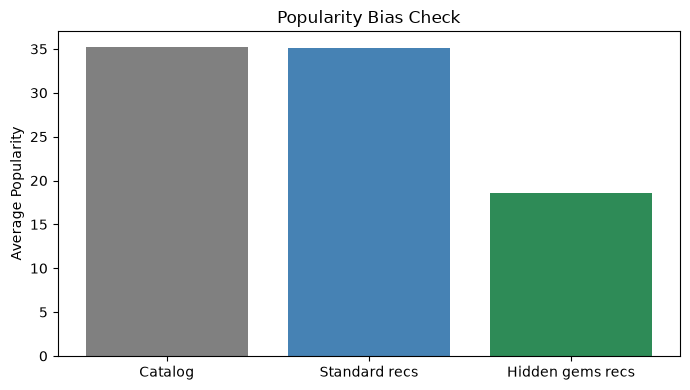

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Catalog", "Standard recs", "Hidden gems recs"],
       [X_train['popularity'].mean(), np.mean(all_recs_popularity), np.mean(all_recs_popularity_hidden)],
       color=["gray", "steelblue", "seagreen"])
ax.set_ylabel("Average Popularity")
ax.set_title("Popularity Bias Check")
plt.tight_layout(); plt.show()

Standard recommendations show virtually no popularity bias (35.1 vs 35.2 catalog average), confirming the design choice to exclude popularity and artist-average-popularity from the similarity feature space. The hidden-gems mode made appear lower popularity tracks (18.6), since the regression model rarely predicts above ~70 (see regression notebook), a large positive residual requires a low popularity value. So the hidden gems can be interpreted as audio-similar tracks with low observed popularity rather than a pure measure of underrated popularity.

#### Summary
This recommender system uses 2 artifacts from earlier notebooks: the K=5 macro-genre mapping(classification) and the tuned regression model (popularity), directly connecting all three stages of the projects.

Known limitations: recommendations can be dominated by a single artist with a consistent production style, and the usage of native genres limits precision for user seeking genre-specific discovery over pure audio similarity.